# PhysioNet: exploratory Gaussian noise in the EEGNet embedding

This notebook completes the Gaussian-noise arm with the **same five subject
folds and the same cached EEGNet embeddings** used by the corrected feature-
masking experiment.

The sweep is exploratory: every tested noise level is reported. No noise
level is selected or described as an independently validated optimum.

Protocol for every outer fold:

- EEGNet was fitted only on runs 4 and 8 from 40 outer-training subjects.
- Utility is evaluated on run 12 from 10 unseen outer-test subjects.
- Identity attackers are fitted on runs 4 and 8 from those 10 test subjects
  and evaluated on their independent run 12 recordings.
- Gaussian noise is independently drawn for utility, attacker training, and
  attacker testing.
- Logistic Regression and Random Forest are retrained at every noise level,
  making them adaptive attackers.
- Three noise draws are averaged **within each fold**. Confidence intervals
  use only the five independent subject folds (n=5), never the 15 draws.

In [1]:
from google.colab import drive
drive.mount("/content/drive")
get_ipython().system('pip -q install "scikit-learn>=1.4,<2" matplotlib')

Mounted at /content/drive


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

SEED = 42
TRAIN_RUNS = [4, 8]
TEST_RUN = 12
N_FOLDS = 5
N_REPEATS = 3
SIGMAS = [0.00, 0.05, 0.10, 0.20, 0.30, 0.50, 0.75, 1.00]
T_CRIT_DF4 = 2.7764451051977987

DRIVE_ROOT = Path("/content/drive/MyDrive/URV_Datasets")
PHYSIONET_DIR = DRIVE_ROOT / "PhysioNet_MI"
CACHE_DIR = PHYSIONET_DIR / "eegnet_embedding_masking_cache"
RESULTS_DIR = PHYSIONET_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

NPZ_CANDIDATES = [
    DRIVE_ROOT / "physionet_mi_lr_imagery_subjects_1_50_with_runs.npz",
    PHYSIONET_DIR / "processed" / "physionet_mi_lr_imagery_subjects_1_50_with_runs.npz",
    PHYSIONET_DIR / "processed" / "physionet_mi_lr_imagery_subjects_1_50.npz",
]

DETAIL_FILE = RESULTS_DIR / "physionet_eegnet_gaussian_detailed.csv"
FOLD_FILE = RESULTS_DIR / "physionet_eegnet_gaussian_fold_summary.csv"
SUMMARY_FILE = RESULTS_DIR / "physionet_eegnet_gaussian_summary.csv"
COMPARISON_FILE = RESULTS_DIR / "physionet_eegnet_gaussian_exploratory_curve.csv"
FIGURE_FILE = RESULTS_DIR / "physionet_eegnet_gaussian_exploratory_curve.png"
RUN_FILE = RESULTS_DIR / "physionet_eegnet_gaussian_run.json"

dataset_path = next((path for path in NPZ_CANDIDATES if path.exists()), None)
assert dataset_path is not None, (
    "Could not find the PhysioNet NPZ. Checked:\n"
    + "\n".join(str(path) for path in NPZ_CANDIDATES)
)
assert CACHE_DIR.exists(), (
    f"Missing {CACHE_DIR}. Run 03_PhysioNet_EEGNet_Improved_Feature_Masking "
    "first so the fold-specific EEGNet embeddings are available."
)
print("Dataset:", dataset_path)
print("Embedding cache:", CACHE_DIR)
print("This experiment runs on CPU; a GPU is not required.")

Dataset: /content/drive/MyDrive/URV_Datasets/physionet_mi_lr_imagery_subjects_1_50_with_runs.npz
Embedding cache: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/eegnet_embedding_masking_cache
This experiment runs on CPU; a GPU is not required.


## 1. Load labels and reconstruct the validated subject folds

In [3]:
data = np.load(dataset_path, allow_pickle=True)
print("NPZ keys:", data.files)

y_raw = np.asarray(data["y"])
y_utility = LabelEncoder().fit_transform(y_raw).astype(np.int64)

if "subject_ids" in data.files:
    subject_ids = np.asarray(data["subject_ids"]).astype(np.int64)
elif "subjects" in data.files:
    subject_ids = np.asarray(data["subjects"]).astype(np.int64)
else:
    raise KeyError("The NPZ contains no subject_ids/subjects array.")

if "run_ids" in data.files:
    run_ids = np.asarray(data["run_ids"]).astype(np.int64)
else:
    print("run_ids missing; validating ordered 30-trial run blocks...")
    run_ids = np.empty(len(subject_ids), dtype=np.int64)
    for subject in np.unique(subject_ids):
        idx = np.flatnonzero(subject_ids == subject)
        assert len(idx) == 90, (
            f"Subject {subject} has {len(idx)} trials; cannot infer run IDs safely."
        )
        assert np.array_equal(idx, np.arange(idx.min(), idx.max() + 1))
        for block, run in enumerate([4, 8, 12]):
            block_idx = idx[block * 30:(block + 1) * 30]
            labels, counts = np.unique(y_utility[block_idx], return_counts=True)
            assert set(labels.tolist()) == {0, 1}
            assert counts.min() == counts.max() == 15
            run_ids[block_idx] = run

assert len(y_utility) == len(subject_ids) == len(run_ids)
assert len(np.unique(subject_ids)) == 50
assert set(np.unique(run_ids).tolist()) == {4, 8, 12}
assert set(np.unique(y_utility).tolist()) == {0, 1}

unique_subjects = np.unique(subject_ids)
outer_cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_splits = list(outer_cv.split(unique_subjects))

print("Trials:", len(y_utility))
print("Subjects:", len(unique_subjects))
print("Runs:", dict(zip(*np.unique(run_ids, return_counts=True))))
print("Utility labels:", dict(zip(*np.unique(y_utility, return_counts=True))))

NPZ keys: ['X', 'y', 'subject_ids', 'run_ids']
Trials: 2245
Subjects: 50
Runs: {np.int64(4): np.int64(750), np.int64(8): np.int64(747), np.int64(12): np.int64(748)}
Utility labels: {np.int64(0): np.int64(1132), np.int64(1): np.int64(1113)}


## 2. Gaussian mechanism and adaptive attackers

`sigma` is expressed in units of the fold-specific standard deviation of
each embedding coordinate. That scale is estimated only from outer-training
subjects. This is an empirical perturbation experiment, not a formal
differential-privacy guarantee.

In [4]:
def add_gaussian_noise(X, feature_scale, sigma, seed):
    X = np.asarray(X, dtype=np.float32)
    if sigma == 0:
        return X.copy()
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, 1.0, size=X.shape).astype(np.float32)
    return X + np.float32(sigma) * feature_scale * noise


def dense_head_predict(embeddings, kernel, bias):
    logits = embeddings @ kernel + bias
    return np.argmax(logits, axis=1)


def build_logistic_attacker(seed):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=seed,
        )),
    ])


def build_rf_attacker(seed):
    return RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        min_samples_leaf=1,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=seed,
    )


def metric_row(fold, sigma, repeat, task, attacker, y_true, y_pred):
    return {
        "fold": fold,
        "sigma": float(sigma),
        "repeat": repeat,
        "task": task,
        "attacker": attacker,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "n_train": np.nan if task == "utility" else 0,
        "n_test": len(y_true),
    }

## 3. Run the complete exploratory sweep

In [5]:
rows = []
fold_metadata = []

for fold, (outer_train_pos, outer_test_pos) in enumerate(fold_splits, start=1):
    outer_train_subjects = unique_subjects[outer_train_pos]
    outer_test_subjects = unique_subjects[outer_test_pos]

    utility_scale_idx = np.flatnonzero(
        np.isin(subject_ids, outer_train_subjects)
        & np.isin(run_ids, TRAIN_RUNS)
    )
    utility_test_idx = np.flatnonzero(
        np.isin(subject_ids, outer_test_subjects) & (run_ids == TEST_RUN)
    )
    privacy_train_idx = np.flatnonzero(
        np.isin(subject_ids, outer_test_subjects)
        & np.isin(run_ids, TRAIN_RUNS)
    )
    privacy_test_idx = np.flatnonzero(
        np.isin(subject_ids, outer_test_subjects) & (run_ids == TEST_RUN)
    )

    assert np.array_equal(utility_test_idx, privacy_test_idx)
    assert not set(outer_train_subjects).intersection(set(outer_test_subjects))
    assert set(np.unique(subject_ids[privacy_train_idx])) == set(outer_test_subjects)
    assert set(np.unique(subject_ids[privacy_test_idx])) == set(outer_test_subjects)

    cache_file = CACHE_DIR / f"fold_{fold}_eegnet_embeddings.npz"
    assert cache_file.exists(), f"Missing cache: {cache_file}"
    cached = np.load(cache_file, allow_pickle=False)
    embeddings = cached["embeddings"].astype(np.float32)
    dense_kernel = cached["dense_kernel"].astype(np.float32)
    dense_bias = cached["dense_bias"].astype(np.float32)

    assert len(embeddings) == len(y_utility)
    assert embeddings.ndim == 2
    assert dense_kernel.shape == (embeddings.shape[1], 2)
    assert dense_bias.shape == (2,)

    feature_scale = embeddings[utility_scale_idx].std(axis=0).astype(np.float32)
    feature_scale = np.maximum(feature_scale, np.float32(1e-6))

    privacy_encoder = LabelEncoder()
    y_privacy_train = privacy_encoder.fit_transform(subject_ids[privacy_train_idx])
    y_privacy_test = privacy_encoder.transform(subject_ids[privacy_test_idx])
    assert len(privacy_encoder.classes_) == 10

    fold_metadata.append({
        "fold": fold,
        "outer_train_subjects": outer_train_subjects.tolist(),
        "outer_test_subjects": outer_test_subjects.tolist(),
        "embedding_dimensions": int(embeddings.shape[1]),
        "utility_scale_trials": int(len(utility_scale_idx)),
        "utility_test_trials": int(len(utility_test_idx)),
        "privacy_train_trials": int(len(privacy_train_idx)),
        "privacy_test_trials": int(len(privacy_test_idx)),
    })

    print(
        f"Fold {fold}: {len(outer_train_subjects)} outer-train subjects, "
        f"{len(outer_test_subjects)} outer-test subjects, "
        f"embedding={embeddings.shape[1]}"
    )

    for sigma_index, sigma in enumerate(SIGMAS):
        for repeat in range(1, N_REPEATS + 1):
            seed_base = SEED + 100_000 * fold + 1_000 * sigma_index + 10 * repeat

            utility_test_noisy = add_gaussian_noise(
                embeddings[utility_test_idx], feature_scale, sigma, seed_base + 1
            )
            utility_pred = dense_head_predict(
                utility_test_noisy, dense_kernel, dense_bias
            )
            utility_row = metric_row(
                fold, sigma, repeat, "utility", "EEGNet frozen Dense head",
                y_utility[utility_test_idx], utility_pred,
            )
            utility_row["n_train"] = len(utility_scale_idx)
            rows.append(utility_row)

            privacy_train_noisy = add_gaussian_noise(
                embeddings[privacy_train_idx], feature_scale, sigma, seed_base + 2
            )
            privacy_test_noisy = add_gaussian_noise(
                embeddings[privacy_test_idx], feature_scale, sigma, seed_base + 3
            )

            attackers = {
                "Logistic Regression": build_logistic_attacker(seed_base + 4),
                "Random Forest": build_rf_attacker(seed_base + 5),
            }
            for attacker_name, attacker in attackers.items():
                attacker.fit(privacy_train_noisy, y_privacy_train)
                privacy_pred = attacker.predict(privacy_test_noisy)
                privacy_row = metric_row(
                    fold, sigma, repeat, "privacy", attacker_name,
                    y_privacy_test, privacy_pred,
                )
                privacy_row["n_train"] = len(privacy_train_idx)
                rows.append(privacy_row)

        print(f"  sigma={sigma:.2f}: completed {N_REPEATS} independent draws")

results = pd.DataFrame(rows)
assert len(results) == N_FOLDS * len(SIGMAS) * N_REPEATS * 3
results.to_csv(DETAIL_FILE, index=False)
results.head()

Fold 1: 40 outer-train subjects, 10 outer-test subjects, embedding=320
  sigma=0.00: completed 3 independent draws
  sigma=0.05: completed 3 independent draws
  sigma=0.10: completed 3 independent draws
  sigma=0.20: completed 3 independent draws
  sigma=0.30: completed 3 independent draws
  sigma=0.50: completed 3 independent draws
  sigma=0.75: completed 3 independent draws
  sigma=1.00: completed 3 independent draws
Fold 2: 40 outer-train subjects, 10 outer-test subjects, embedding=320
  sigma=0.00: completed 3 independent draws
  sigma=0.05: completed 3 independent draws
  sigma=0.10: completed 3 independent draws
  sigma=0.20: completed 3 independent draws
  sigma=0.30: completed 3 independent draws
  sigma=0.50: completed 3 independent draws
  sigma=0.75: completed 3 independent draws
  sigma=1.00: completed 3 independent draws
Fold 3: 40 outer-train subjects, 10 outer-test subjects, embedding=320
  sigma=0.00: completed 3 independent draws
  sigma=0.05: completed 3 independent d

,fold,sigma,repeat,task,attacker,accuracy,balanced_accuracy,macro_f1,n_train,n_test
0,1,0.0,1,utility,EEGNet frozen Dense head,0.673333,0.672119,0.670034,1197,150
1,1,0.0,1,privacy,Logistic Regression,0.606667,0.606667,0.600981,300,150
2,1,0.0,1,privacy,Random Forest,0.486667,0.486667,0.475699,300,150
3,1,0.0,2,utility,EEGNet frozen Dense head,0.673333,0.672119,0.670034,1197,150
4,1,0.0,2,privacy,Logistic Regression,0.606667,0.606667,0.600981,300,150


## 4. Fold-level inference

The three noise draws are collapsed first. The inferential unit is therefore
the subject fold (n=5), not each random draw.

In [6]:
fold_results = (
    results
    .groupby(["fold", "sigma", "task", "attacker"], as_index=False)
    .agg(
        accuracy=("accuracy", "mean"),
        balanced_accuracy=("balanced_accuracy", "mean"),
        macro_f1=("macro_f1", "mean"),
        n_noise_draws=("repeat", "nunique"),
        n_train=("n_train", "first"),
        n_test=("n_test", "first"),
    )
)

baseline = (
    fold_results[fold_results["sigma"] == 0]
    [["fold", "task", "attacker", "balanced_accuracy"]]
    .rename(columns={"balanced_accuracy": "baseline_balanced_accuracy"})
)
fold_results = fold_results.merge(
    baseline, on=["fold", "task", "attacker"], how="left", validate="many_to_one"
)
fold_results["change_from_zero"] = np.where(
    fold_results["task"].eq("privacy"),
    fold_results["baseline_balanced_accuracy"] - fold_results["balanced_accuracy"],
    fold_results["balanced_accuracy"] - fold_results["baseline_balanced_accuracy"],
)
fold_results["change_interpretation"] = np.where(
    fold_results["task"].eq("privacy"),
    "positive = less identity leakage",
    "positive = higher utility",
)
fold_results.to_csv(FOLD_FILE, index=False)


def summarise_five_folds(group):
    n = group["fold"].nunique()
    assert n == N_FOLDS
    output = {"n_folds": n}
    for metric in ["accuracy", "balanced_accuracy", "macro_f1", "change_from_zero"]:
        values = group[metric].to_numpy(dtype=float)
        mean = values.mean()
        sd = values.std(ddof=1)
        sem = sd / np.sqrt(n)
        margin = T_CRIT_DF4 * sem
        output[f"{metric}_mean"] = mean
        output[f"{metric}_sd"] = sd
        output[f"{metric}_sem"] = sem
        output[f"{metric}_ci95_low"] = mean - margin
        output[f"{metric}_ci95_high"] = mean + margin
    return pd.Series(output)


summary = (
    fold_results
    .groupby(["sigma", "task", "attacker"], as_index=False)
    .apply(summarise_five_folds, include_groups=False)
    .reset_index(drop=True)
)
summary.to_csv(SUMMARY_FILE, index=False)

utility_curve = (
    summary[summary["task"] == "utility"]
    .drop(columns=["task", "attacker"])
    .add_prefix("utility_")
    .rename(columns={"utility_sigma": "sigma"})
)
lr_curve = (
    summary[(summary["task"] == "privacy") &
            (summary["attacker"] == "Logistic Regression")]
    .drop(columns=["task", "attacker"])
    .add_prefix("lr_privacy_")
    .rename(columns={"lr_privacy_sigma": "sigma"})
)
rf_curve = (
    summary[(summary["task"] == "privacy") &
            (summary["attacker"] == "Random Forest")]
    .drop(columns=["task", "attacker"])
    .add_prefix("rf_privacy_")
    .rename(columns={"rf_privacy_sigma": "sigma"})
)
comparison = utility_curve.merge(lr_curve, on="sigma", validate="one_to_one")
comparison = comparison.merge(rf_curve, on="sigma", validate="one_to_one")
comparison.to_csv(COMPARISON_FILE, index=False)

display_columns = [
    "sigma",
    "utility_balanced_accuracy_mean",
    "lr_privacy_balanced_accuracy_mean",
    "rf_privacy_balanced_accuracy_mean",
    "utility_change_from_zero_mean",
    "lr_privacy_change_from_zero_mean",
    "rf_privacy_change_from_zero_mean",
]
display(comparison[display_columns].style.format("{:.4f}"))

,sigma,utility_balanced_accuracy_mean,lr_privacy_balanced_accuracy_mean,rf_privacy_balanced_accuracy_mean,utility_change_from_zero_mean,lr_privacy_change_from_zero_mean,rf_privacy_change_from_zero_mean
0,0.0000,0.6661,0.6410,0.5386,0.0000,0.0000,0.0000
1,0.0500,0.6643,0.6366,0.5369,-0.0017,0.0044,0.0017
2,0.1000,0.6643,0.6357,0.5283,-0.0018,0.0053,0.0103
3,0.2000,0.6685,0.6286,0.5390,0.0024,0.0124,-0.0004
4,0.3000,0.6635,0.6035,0.5232,-0.0025,0.0376,0.0154
5,0.5000,0.6631,0.5683,0.4936,-0.0030,0.0727,0.0450
6,0.7500,0.6649,0.5152,0.4833,-0.0012,0.1259,0.0553
7,1.0000,0.6605,0.4844,0.4321,-0.0056,0.1566,0.1065


## 5. Exploratory curves

Lower privacy-attacker balanced accuracy is better; higher utility balanced
accuracy is better. The dashed line is the matched 10-identity chance level.

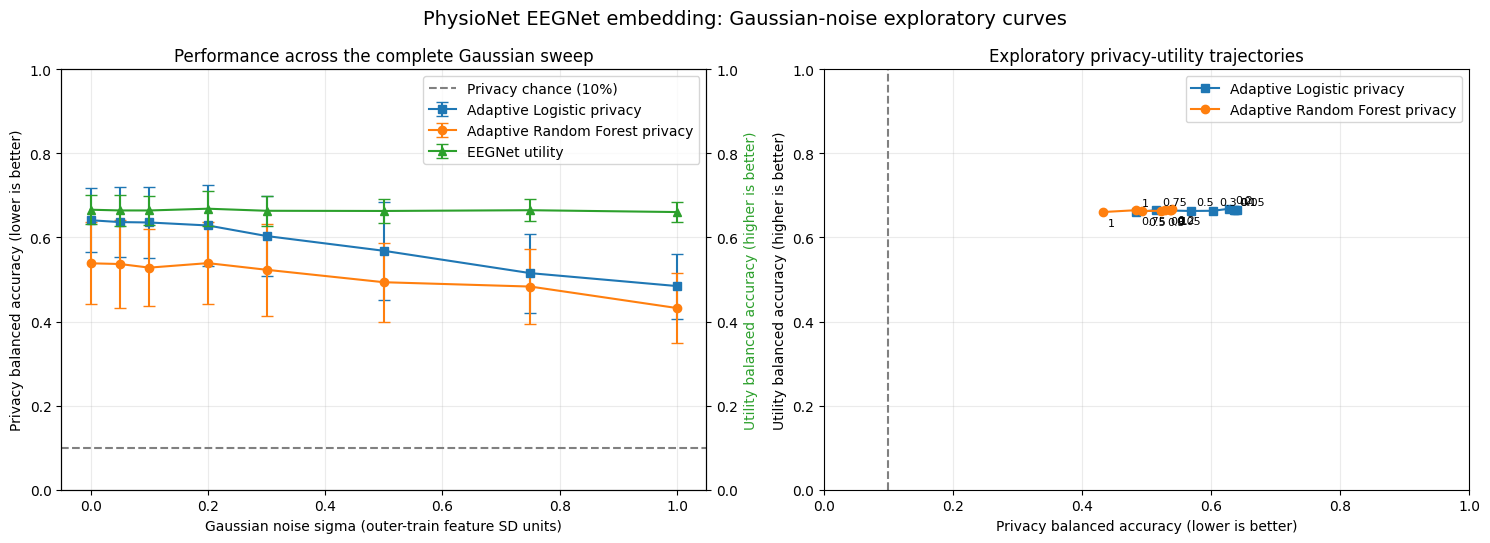

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x = comparison["sigma"].to_numpy()

ax = axes[0]
ax.errorbar(
    x,
    comparison["lr_privacy_balanced_accuracy_mean"],
    yerr=[
        comparison["lr_privacy_balanced_accuracy_mean"]
        - comparison["lr_privacy_balanced_accuracy_ci95_low"],
        comparison["lr_privacy_balanced_accuracy_ci95_high"]
        - comparison["lr_privacy_balanced_accuracy_mean"],
    ],
    marker="s", capsize=4, label="Adaptive Logistic privacy",
)
ax.errorbar(
    x,
    comparison["rf_privacy_balanced_accuracy_mean"],
    yerr=[
        comparison["rf_privacy_balanced_accuracy_mean"]
        - comparison["rf_privacy_balanced_accuracy_ci95_low"],
        comparison["rf_privacy_balanced_accuracy_ci95_high"]
        - comparison["rf_privacy_balanced_accuracy_mean"],
    ],
    marker="o", capsize=4, label="Adaptive Random Forest privacy",
)
ax.axhline(0.10, color="gray", linestyle="--", label="Privacy chance (10%)")
ax.set_xlabel("Gaussian noise sigma (outer-train feature SD units)")
ax.set_ylabel("Privacy balanced accuracy (lower is better)")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)

utility_ax = ax.twinx()
utility_ax.errorbar(
    x,
    comparison["utility_balanced_accuracy_mean"],
    yerr=[
        comparison["utility_balanced_accuracy_mean"]
        - comparison["utility_balanced_accuracy_ci95_low"],
        comparison["utility_balanced_accuracy_ci95_high"]
        - comparison["utility_balanced_accuracy_mean"],
    ],
    color="tab:green", marker="^", capsize=4, label="EEGNet utility",
)
utility_ax.set_ylabel("Utility balanced accuracy (higher is better)", color="tab:green")
utility_ax.set_ylim(0, 1)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = utility_ax.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="best")
ax.set_title("Performance across the complete Gaussian sweep")

ax = axes[1]
utility = comparison["utility_balanced_accuracy_mean"].to_numpy()
lr_privacy = comparison["lr_privacy_balanced_accuracy_mean"].to_numpy()
rf_privacy = comparison["rf_privacy_balanced_accuracy_mean"].to_numpy()
ax.plot(lr_privacy, utility, marker="s", label="Adaptive Logistic privacy")
ax.plot(rf_privacy, utility, marker="o", label="Adaptive Random Forest privacy")
for sigma, px, py in zip(x, lr_privacy, utility):
    ax.annotate(f"{sigma:g}", (px, py), xytext=(4, 4), textcoords="offset points", fontsize=8)
for sigma, px, py in zip(x, rf_privacy, utility):
    ax.annotate(f"{sigma:g}", (px, py), xytext=(4, -10), textcoords="offset points", fontsize=8)
ax.axvline(0.10, color="gray", linestyle="--")
ax.set_xlabel("Privacy balanced accuracy (lower is better)")
ax.set_ylabel("Utility balanced accuracy (higher is better)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(loc="best")
ax.set_title("Exploratory privacy-utility trajectories")

fig.suptitle("PhysioNet EEGNet embedding: Gaussian-noise exploratory curves", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_FILE, dpi=220, bbox_inches="tight")
plt.show()

## 6. Save provenance

In [8]:
run_metadata = {
    "experiment": "PhysioNet EEGNet embedding Gaussian-noise exploratory sweep",
    "selection_status": "exploratory full curve; no independently validated optimum",
    "dataset_path": str(dataset_path),
    "cache_directory": str(CACHE_DIR),
    "seed": SEED,
    "train_runs": TRAIN_RUNS,
    "test_run": TEST_RUN,
    "n_folds": N_FOLDS,
    "n_noise_draws_per_fold_sigma": N_REPEATS,
    "sigmas": SIGMAS,
    "privacy_chance": 0.10,
    "noise_scale": "per-feature SD estimated from outer-training subjects, runs 4 and 8",
    "adaptive_attackers": ["Logistic Regression", "Random Forest (500 trees)"],
    "inference": "noise draws averaged within fold; t 95% CI across five subject folds",
    "formal_dp_guarantee": False,
    "folds": fold_metadata,
    "outputs": {
        "detailed": str(DETAIL_FILE),
        "fold_summary": str(FOLD_FILE),
        "summary": str(SUMMARY_FILE),
        "exploratory_curve": str(COMPARISON_FILE),
        "figure": str(FIGURE_FILE),
    },
}
with open(RUN_FILE, "w") as handle:
    json.dump(run_metadata, handle, indent=2)

print("Saved detailed results:", DETAIL_FILE)
print("Saved independent fold summary:", FOLD_FILE)
print("Saved overall summary:", SUMMARY_FILE)
print("Saved exploratory curve:", COMPARISON_FILE)
print("Saved figure:", FIGURE_FILE)
print("Saved run metadata:", RUN_FILE)
print("\nInterpret the complete curve. Do not label a post-hoc sigma as validated best.")

Saved detailed results: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_gaussian_detailed.csv
Saved independent fold summary: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_gaussian_fold_summary.csv
Saved overall summary: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_gaussian_summary.csv
Saved exploratory curve: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_gaussian_exploratory_curve.csv
Saved figure: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_gaussian_exploratory_curve.png
Saved run metadata: /content/drive/MyDrive/URV_Datasets/PhysioNet_MI/results/physionet_eegnet_gaussian_run.json

Interpret the complete curve. Do not label a post-hoc sigma as validated best.
